# Imports

In [1]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib

# Model And Data Loading

In [ ]:
# model = joblib.load('../models/random_forest.pkl')
# model = joblib.load('../models/XGBoost.pkl')
model = joblib.load('../models/best_model_v1.pkl')

X_test = pd.read_parquet('../data/processed/X_test.parquet')
y_test = pd.read_parquet('../data/processed/y_test.parquet').squeeze()

# Metrics

In [3]:
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

In [4]:
print(classification_report(y_test, pred))
print('ROC-AUC: ', roc_auc_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.76      0.75      0.76      2806
           1       0.69      0.70      0.69      2194

    accuracy                           0.73      5000
   macro avg       0.72      0.72      0.72      5000
weighted avg       0.73      0.73      0.73      5000

ROC-AUC:  0.7877127635727843


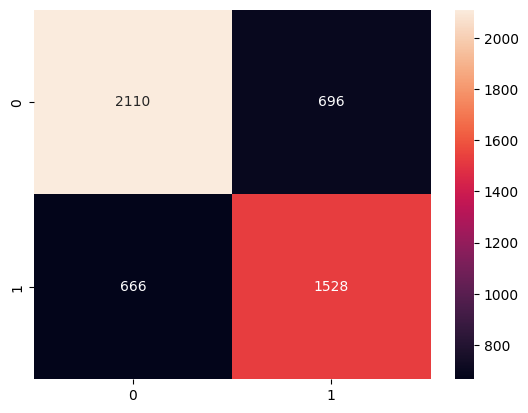

In [5]:
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d')
plt.show()

In [6]:
confusion_matrix(y_test, pred)

array([[2110,  696],
       [ 666, 1528]])

# Feature Importance

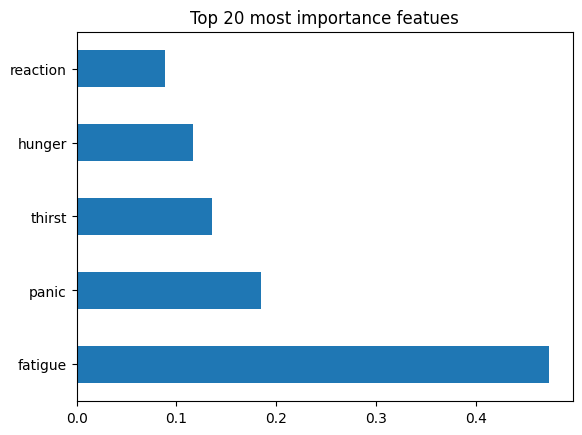

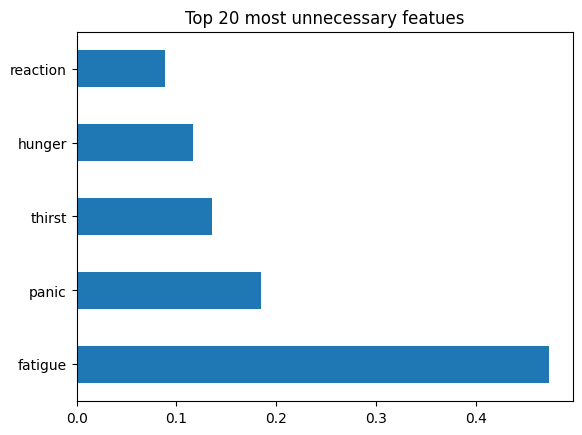

In [7]:
importances = pd.Series(model.feature_importances_, index=X_test.columns)
importances.sort_values(ascending=False).head(20).plot(kind='barh')
plt.title('Top 20 most importance featues')
plt.show()
importances.sort_values(ascending=False).tail(20).plot(kind='barh')
plt.title('Top 20 most unnecessary featues')
plt.show()

In [ ]:
# df_temp = pd.read_csv('../data/raw/backrooms_survival_v4.csv')

# dataframe_for_pydantic = df_temp[['fatigue', 'panic', 'thirst', 'reaction', 'hunger', 'survived_24h']]
# dataframe_for_pydantic.to_csv('../data/processed/streamlit_test.csv', sep=',', index=False)

In [ ]:
# df_streamlit = pd.read_csv('../data/processed/streamlit_test.csv')
# df_streamlit.describe()

,fatigue,panic,thirst,reaction,hunger,survived_24h
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,63.235200,52.320500,54.056600,4.705650,54.37125,0.438750
std,19.320785,18.199301,20.332808,1.464211,19.61045,0.496247
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,50.000000,39.000000,41.000000,4.000000,42.00000,0.000000
50%,64.000000,51.000000,56.000000,5.000000,56.00000,0.000000
75%,78.000000,65.000000,69.000000,6.000000,68.00000,1.000000
max,100.000000,100.000000,100.000000,10.000000,100.00000,1.000000
